In [42]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt

In [43]:
# Use a faster model first
model = pybamm.lithium_ion.SPM()

# LFP parameter set
parameter_values = pybamm.ParameterValues("Prada2013")

# 1000 cycles at 10C
experiment = pybamm.Experiment(
    [
        (
            "Discharge at 1C until 2.5 V",
            "Charge at 1C until 3.65 V",
            "Hold at 3.65 V until C/20",
        )
    ] * 1000
)

solver = pybamm.IDAKLUSolver()

sim = pybamm.Simulation(
    model,
    parameter_values=parameter_values,
    experiment=experiment,
    solver=solver,
)

solution = sim.solve()

['Time [s]', 'Time [h]', 'Throughput capacity [A.h]', 'Throughput energy [W.h]', 'Loss of lithium inventory [%]', 'Loss of lithium inventory, including electrolyte [%]', 'Total lithium [mol]', 'Total lithium in electrolyte [mol]', 'Total lithium in particles [mol]', 'Total lithium lost [mol]', 'Total lithium lost from particles [mol]', 'Total lithium lost from electrolyte [mol]', 'Loss of lithium to negative SEI [mol]', 'Loss of capacity to negative SEI [A.h]', 'Loss of lithium to positive SEI [mol]', 'Loss of capacity to positive SEI [A.h]', 'Total lithium lost to side reactions [mol]', 'Total capacity lost to side reactions [A.h]', 'Local ECM resistance [Ohm]', 'Negative electrode capacity [A.h]', 'Loss of active material in negative electrode [%]', 'Total lithium in negative electrode [mol]', 'Loss of lithium to negative lithium plating [mol]', 'Loss of capacity to negative lithium plating [A.h]', 'Loss of lithium to negative SEI on cracks [mol]', 'Loss of capacity to negative SEI o

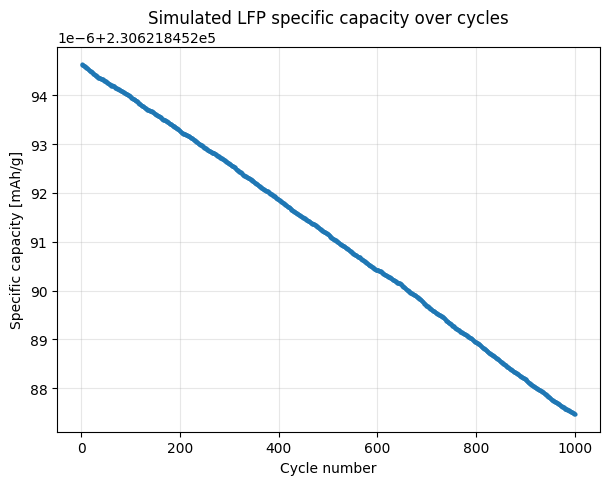

In [ ]:
summary = solution.summary_variables
print(summary.all_variables)

cycles = np.array(summary["Cycle number"])

capacity_mAh = np.array(summary["Capacity [A.h]"]) * 1000

active_mass_g = 0.009988  # example: 5 mg = 0.005 g

specific_capacity = capacity_mAh / active_mass_g

plt.figure(figsize=(7, 5))
plt.plot(cycles, specific_capacity, marker="o", markersize=2, linewidth=1)
plt.xlabel("Cycle number")
plt.ylabel("Specific capacity [mAh/g]")
plt.title("Simulated LFP specific capacity over cycles")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [45]:
print("Specific Capacity in mA.h/g:")
print(specific_capacity[:5])

print("Capacity in mA.h:")
print(capacity_mAh[:5])

Specific Capacity in mA.h/g:
[230621.84529464 230621.84529463 230621.84529463 230621.84529462
 230621.84529461]
Capacity in mA.h:
[2303.4509908 2303.4509908 2303.4509908 2303.4509908 2303.4509908]
